In [1]:
from modules.train import train_model
from modules.model import TumorClassifier, TumorClassifierMBConv
from modules.transforms import train_transform, val_transform, test_transform
from modules.metrics import evaluate_and_report
from modules.train2 import train_model2, train_model3
import torch
from torchvision import datasets
from torch.utils.data import random_split, ConcatDataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TumorClassifierMBConv()
model = model.to(device)

In [3]:
# Load dataset using ImageFolder
train_dataset = datasets.ImageFolder(root="brain_tumor_dataset/Training", transform=train_transform())
test_dataset = datasets.ImageFolder(root="brain_tumor_dataset/Testing", transform=train_transform())
classes = test_dataset.classes
full_dataset = ConcatDataset([train_dataset, test_dataset])

train_dataset, test_dataset = random_split(
    full_dataset,
    [0.7, 0.3],
    generator=torch.Generator().manual_seed(42)
)

In [4]:
train_model3(
    model,
    train_dataset,
    batch_size=32,
    epochs=40,
    lr=0.0003,
    save_path="./training_data/effnet_mixup_finetuned_best_efficientnetB0_steplr.pth",   # save the best model weights
    use_sampler=True,             # if your classes are imbalanced
    scheduler_type="steplr",       # or "cosine"
    use_mixup=True,               # optional: if you want stronger augmentation
    fine_tune_at_epoch=5           # start fine-tuning deeper layers at epoch 5
)

Epoch 1/40 - Loss: 33.9566 - Train Acc: 0.3003 - Val Acc: 0.6258
Epoch 2/40 - Loss: 30.0695 - Train Acc: 0.4196 - Val Acc: 0.6849
Epoch 3/40 - Loss: 27.5153 - Train Acc: 0.4798 - Val Acc: 0.7615
Epoch 4/40 - Loss: 26.5006 - Train Acc: 0.4683 - Val Acc: 0.7418
Epoch 5/40 - Loss: 26.1694 - Train Acc: 0.5317 - Val Acc: 0.7571
Epoch 6: Unfreezing deeper layers for fine-tuning...
Epoch 6/40 - Loss: 22.6408 - Train Acc: 0.4278 - Val Acc: 0.7921
Epoch 7/40 - Loss: 19.4102 - Train Acc: 0.5235 - Val Acc: 0.8162
Epoch 8/40 - Loss: 17.0266 - Train Acc: 0.5755 - Val Acc: 0.8271
Epoch 9/40 - Loss: 16.5085 - Train Acc: 0.5509 - Val Acc: 0.8578
Epoch 10/40 - Loss: 17.0410 - Train Acc: 0.5678 - Val Acc: 0.8643
Epoch 11/40 - Loss: 15.9724 - Train Acc: 0.5897 - Val Acc: 0.8775
Epoch 12/40 - Loss: 14.8887 - Train Acc: 0.6132 - Val Acc: 0.8972
Epoch 13/40 - Loss: 14.3434 - Train Acc: 0.5131 - Val Acc: 0.8993
Epoch 14/40 - Loss: 12.5265 - Train Acc: 0.5405 - Val Acc: 0.9234
Epoch 15/40 - Loss: 13.1305 - Tr

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TumorClassifierMBConv()
model.load_state_dict(torch.load("./training_data/effnet_mixup_finetuned_best_efficientnetB0_steplr.pth"))
model = model.to(device)
model.eval()  # Set the model to evaluation mode

/tmp/ipykernel_852646/3975063088.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./training_data/effnet_mixup_finetuned_best_efficientn

TumorClassifierMBConv(
  (base_model): Sequential(
    (0): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (sca

In [8]:
test_dataset.dataset.transform = val_transform()
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


=== Classification Report ===
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.87      0.92       284
meningioma_tumor       0.85      0.92      0.88       260
        no_tumor       0.94      0.97      0.96       156
 pituitary_tumor       0.96      0.96      0.96       279

        accuracy                           0.93       979
       macro avg       0.93      0.93      0.93       979
    weighted avg       0.93      0.93      0.93       979


=== Test Accuracy: 92.65% ===


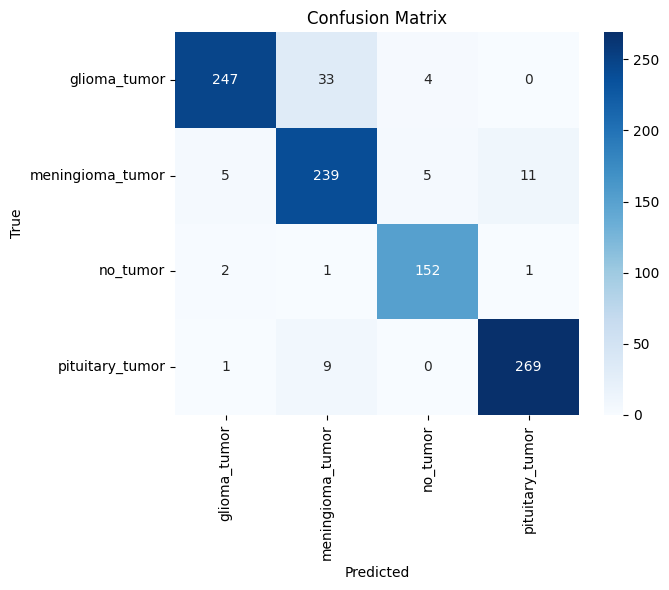

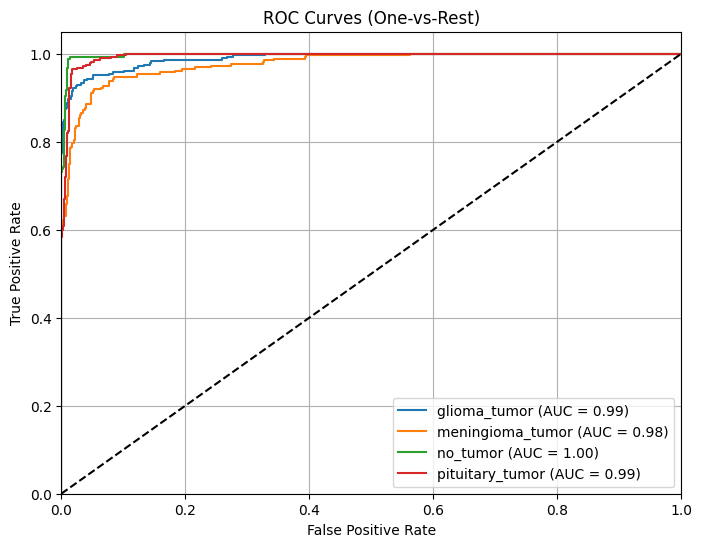

(array([2, 0, 1, 3, 1, 3, 0, 1, 1, 3, 1, 3, 1, 2, 2, 1, 3, 1, 2, 1, 1, 3,
        0, 3, 3, 3, 0, 1, 1, 0, 1, 2, 0, 1, 3, 0, 3, 3, 1, 3, 3, 0, 0, 1,
        1, 3, 0, 0, 0, 2, 3, 0, 3, 3, 1, 3, 3, 0, 3, 3, 2, 3, 0, 0, 2, 2,
        1, 3, 0, 0, 2, 1, 1, 1, 3, 3, 1, 3, 3, 2, 2, 1, 2, 1, 0, 3, 1, 1,
        3, 1, 3, 0, 0, 3, 3, 2, 3, 3, 0, 0, 1, 0, 1, 3, 0, 0, 0, 1, 0, 1,
        3, 1, 1, 0, 2, 2, 0, 0, 2, 1, 3, 1, 3, 3, 3, 3, 1, 2, 1, 1, 3, 0,
        0, 3, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3, 0, 1, 3, 0, 2, 3, 3, 0, 3, 3,
        3, 1, 3, 1, 2, 0, 3, 1, 1, 1, 0, 1, 1, 3, 0, 0, 3, 3, 2, 1, 1, 2,
        1, 0, 0, 1, 0, 0, 2, 0, 0, 1, 2, 1, 3, 1, 1, 0, 1, 1, 2, 1, 1, 1,
        0, 1, 3, 1, 0, 2, 2, 3, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 3, 3, 2, 2,
        0, 3, 1, 3, 3, 2, 1, 0, 0, 2, 2, 2, 3, 3, 3, 0, 3, 0, 3, 1, 3, 1,
        1, 3, 1, 0, 0, 3, 1, 3, 3, 3, 1, 3, 2, 2, 0, 1, 1, 2, 2, 2, 0, 0,
        2, 2, 3, 0, 3, 0, 2, 2, 3, 1, 3, 0, 1, 3, 3, 0, 0, 3, 0, 1, 0, 0,
        2, 2, 1, 0, 2, 0, 3, 3, 1, 0, 

In [9]:
evaluate_and_report(
    model,
    test_loader,
    device,
    classes,
)